In [3]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\Pikachu\AppData\Local\Programs\Python\Python314\python.exe
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("A:\\iam_pikabyte\\CSV_Files&Pdf's\\titanic_data_updated.csv")

In [4]:
df.shape

(891, 12)

In [5]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [6]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
643,644,yes,third,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
780,781,yes,third,"Ayoub, Miss. Banoura",female,13.0,0,0,2687,7.2292,NaN,C
760,761,no,third,"Garfirth, Mr. John",male,NaN,0,0,358585,14.5000,NaN,S
364,365,no,third,"O'Brien, Mr. Thomas",male,NaN,1,0,370365,15.5000,NaN,Q
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
513,514,yes,first,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54.0,1,0,PC 17603,59.4000,NaN,C
810,811,no,third,"Alexander, Mr. William",male,26.0,0,0,3474,7.8875,NaN,S
657,658,no,third,"Bourke, Mrs. John (Catherine)",female,32.0,1,1,364849,15.5000,NaN,Q
734,735,no,second,"Troupiansky, Mr. Moses Aaron",male,23.0,0,0,233639,13.0000,NaN,S
511,512,no,third,"Webber, Mr. James",male,NaN,0,0,SOTON/OQ 3101316,8.0500,NaN,S


In [7]:
# missing Values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# checking duplicacy
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    str    
 2   Pclass       891 non-null    str    
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(3), str(7)
memory usage: 83.7 KB


In [14]:
# Works only with numerical features
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


## Univariate Analysis {Categorical}

<Axes: xlabel='Survived', ylabel='count'>

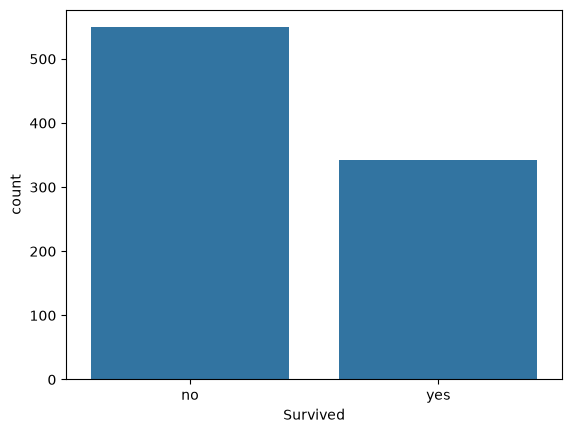

In [15]:
sns.countplot(data=df, x= df["Survived"])

In [17]:
(df['Survived'].value_counts()/len(df))* 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

<StringArray>
['no', 'yes']
Length: 2, dtype: str


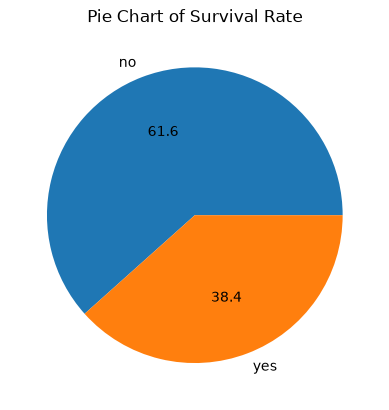

In [22]:
survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()
print(survived_label)
plt.pie(survived_count, labels=survived_label, autopct="%1.1f")
plt.title('Pie Chart of Survival Rate')
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

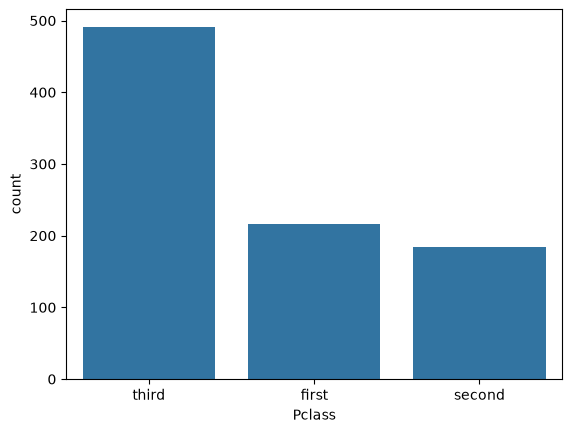

In [23]:
sns.countplot(data=df, x=df['Pclass'])

In [24]:
(df['Pclass'].value_counts()/len(df))*100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

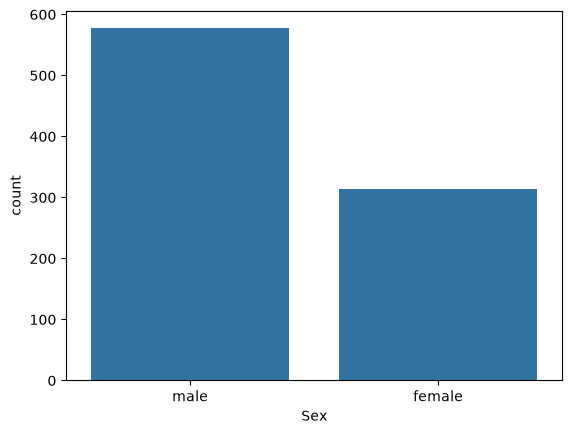

In [26]:
sns.countplot(data=df, x=df['Sex'])

In [27]:
(df['Sex'].value_counts()/len(df))*100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

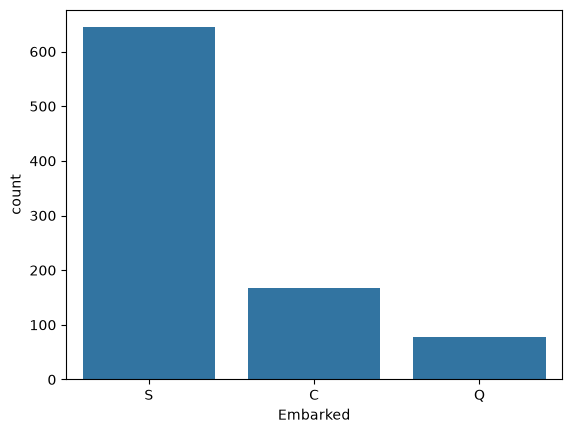

In [28]:
sns.countplot(data=df, x=df['Embarked'])

In [29]:
(df['Embarked'].value_counts()/len(df))*100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

## Univariate Analysis {Numerical}

Text(0, 0.5, 'Frequency')

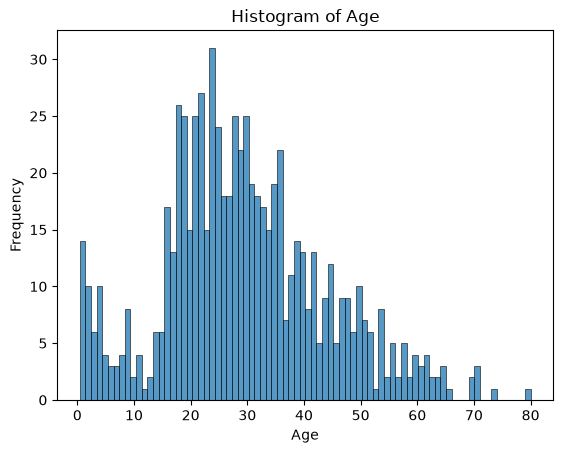

In [33]:
sns.histplot(df['Age'],bins=80)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

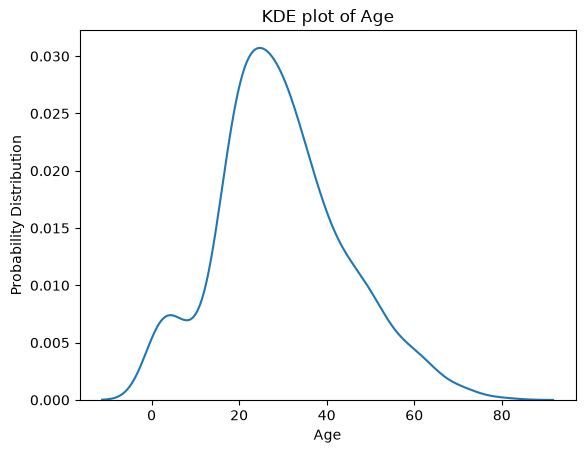

In [34]:
sns.kdeplot(df['Age'])
plt.title('KDE plot of Age')
plt.xlabel('Age')
plt.ylabel('Probability Distribution')
plt.show()

Text(0.5, 1.0, 'Distribution of Fare')

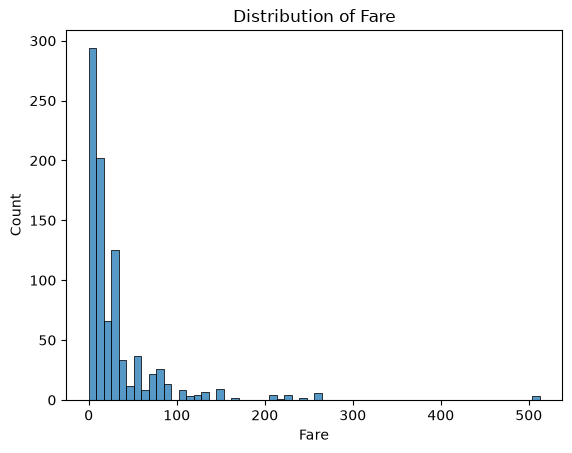

In [36]:
sns.histplot(df['Fare'])
plt.title('Distribution of Fare')

Text(0.5, 1.0, 'Distribution of Fare')

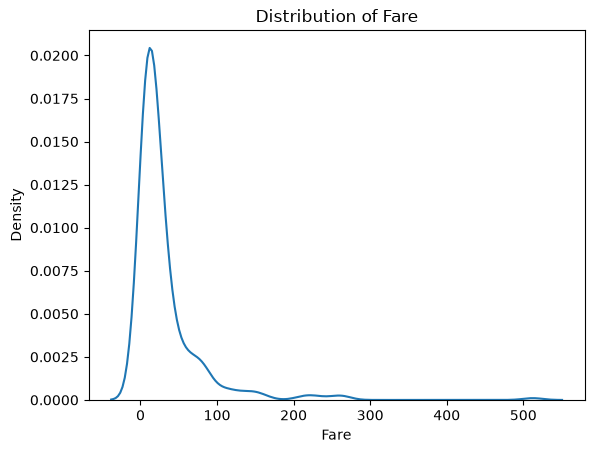

In [37]:
sns.kdeplot(df['Fare'])
plt.title('Distribution of Fare')

<Axes: ylabel='Fare'>

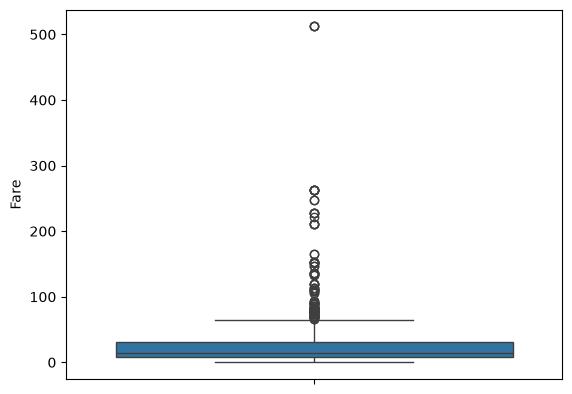

In [38]:
sns.boxplot(df['Fare'])